In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_csv(r"Add Dataset")
df.shape

(2772, 7)

In [2]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
print(df.sex.value_counts())
print(df.smoker.value_counts())
print(df.region.value_counts())

sex
male      1406
female    1366
Name: count, dtype: int64
smoker
no     2208
yes     564
Name: count, dtype: int64
region
southeast    766
southwest    684
northwest    664
northeast    658
Name: count, dtype: int64


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   str    
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   str    
 5   region    2772 non-null   str    
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 195.5 KB


## Drop Duplicates

In [2]:
df = df.drop_duplicates()

<Axes: xlabel='sex', ylabel='age'>

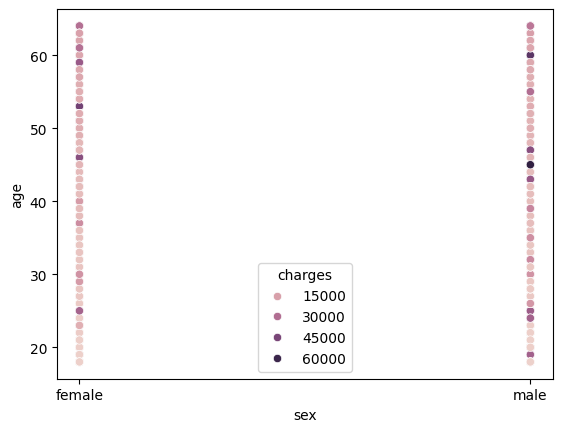

In [14]:
sns.scatterplot(x=df.sex , y=df.age , hue=df.charges)

In [16]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## One Hot encoding 

In [3]:
df = pd.get_dummies(df , columns=['region'] , drop_first=True , dtype=np.int64)

## Encoding using map function

In [4]:
df['sex'] = df['sex'].map({'female': 0 , 'male': 1})
df['smoker'] = df['smoker'].map({'no': 0 , 'yes': 1})

In [7]:
df

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,1,0,0
1334,18,0,31.920,0,0,2205.98080,0,0,0
1335,18,0,36.850,0,0,1629.83350,0,1,0
1336,21,0,25.800,0,0,2007.94500,0,0,1


<Axes: >

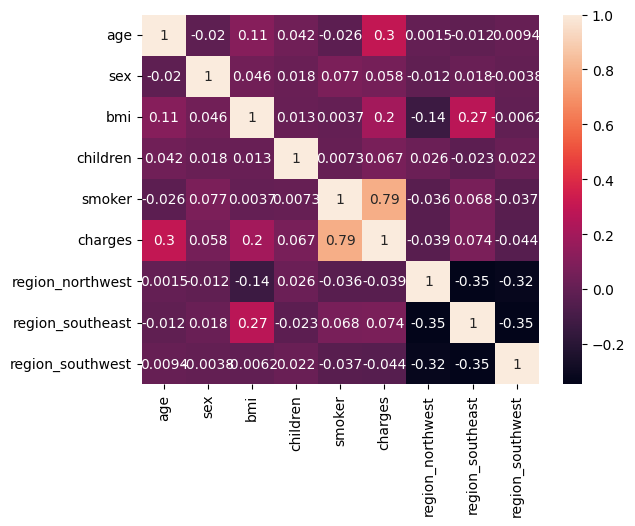

In [23]:
sns.heatmap(df.corr() , annot=True)

In [11]:
print(df.smoker.value_counts())
print(df.children.value_counts())
print(df.region_northwest.value_counts())
print(df.region_southwest.value_counts())

smoker
0    1063
1     274
Name: count, dtype: int64
children
0    573
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64
region_northwest
0    1013
1     324
Name: count, dtype: int64
region_southwest
0    1012
1     325
Name: count, dtype: int64


## Outlier Detection

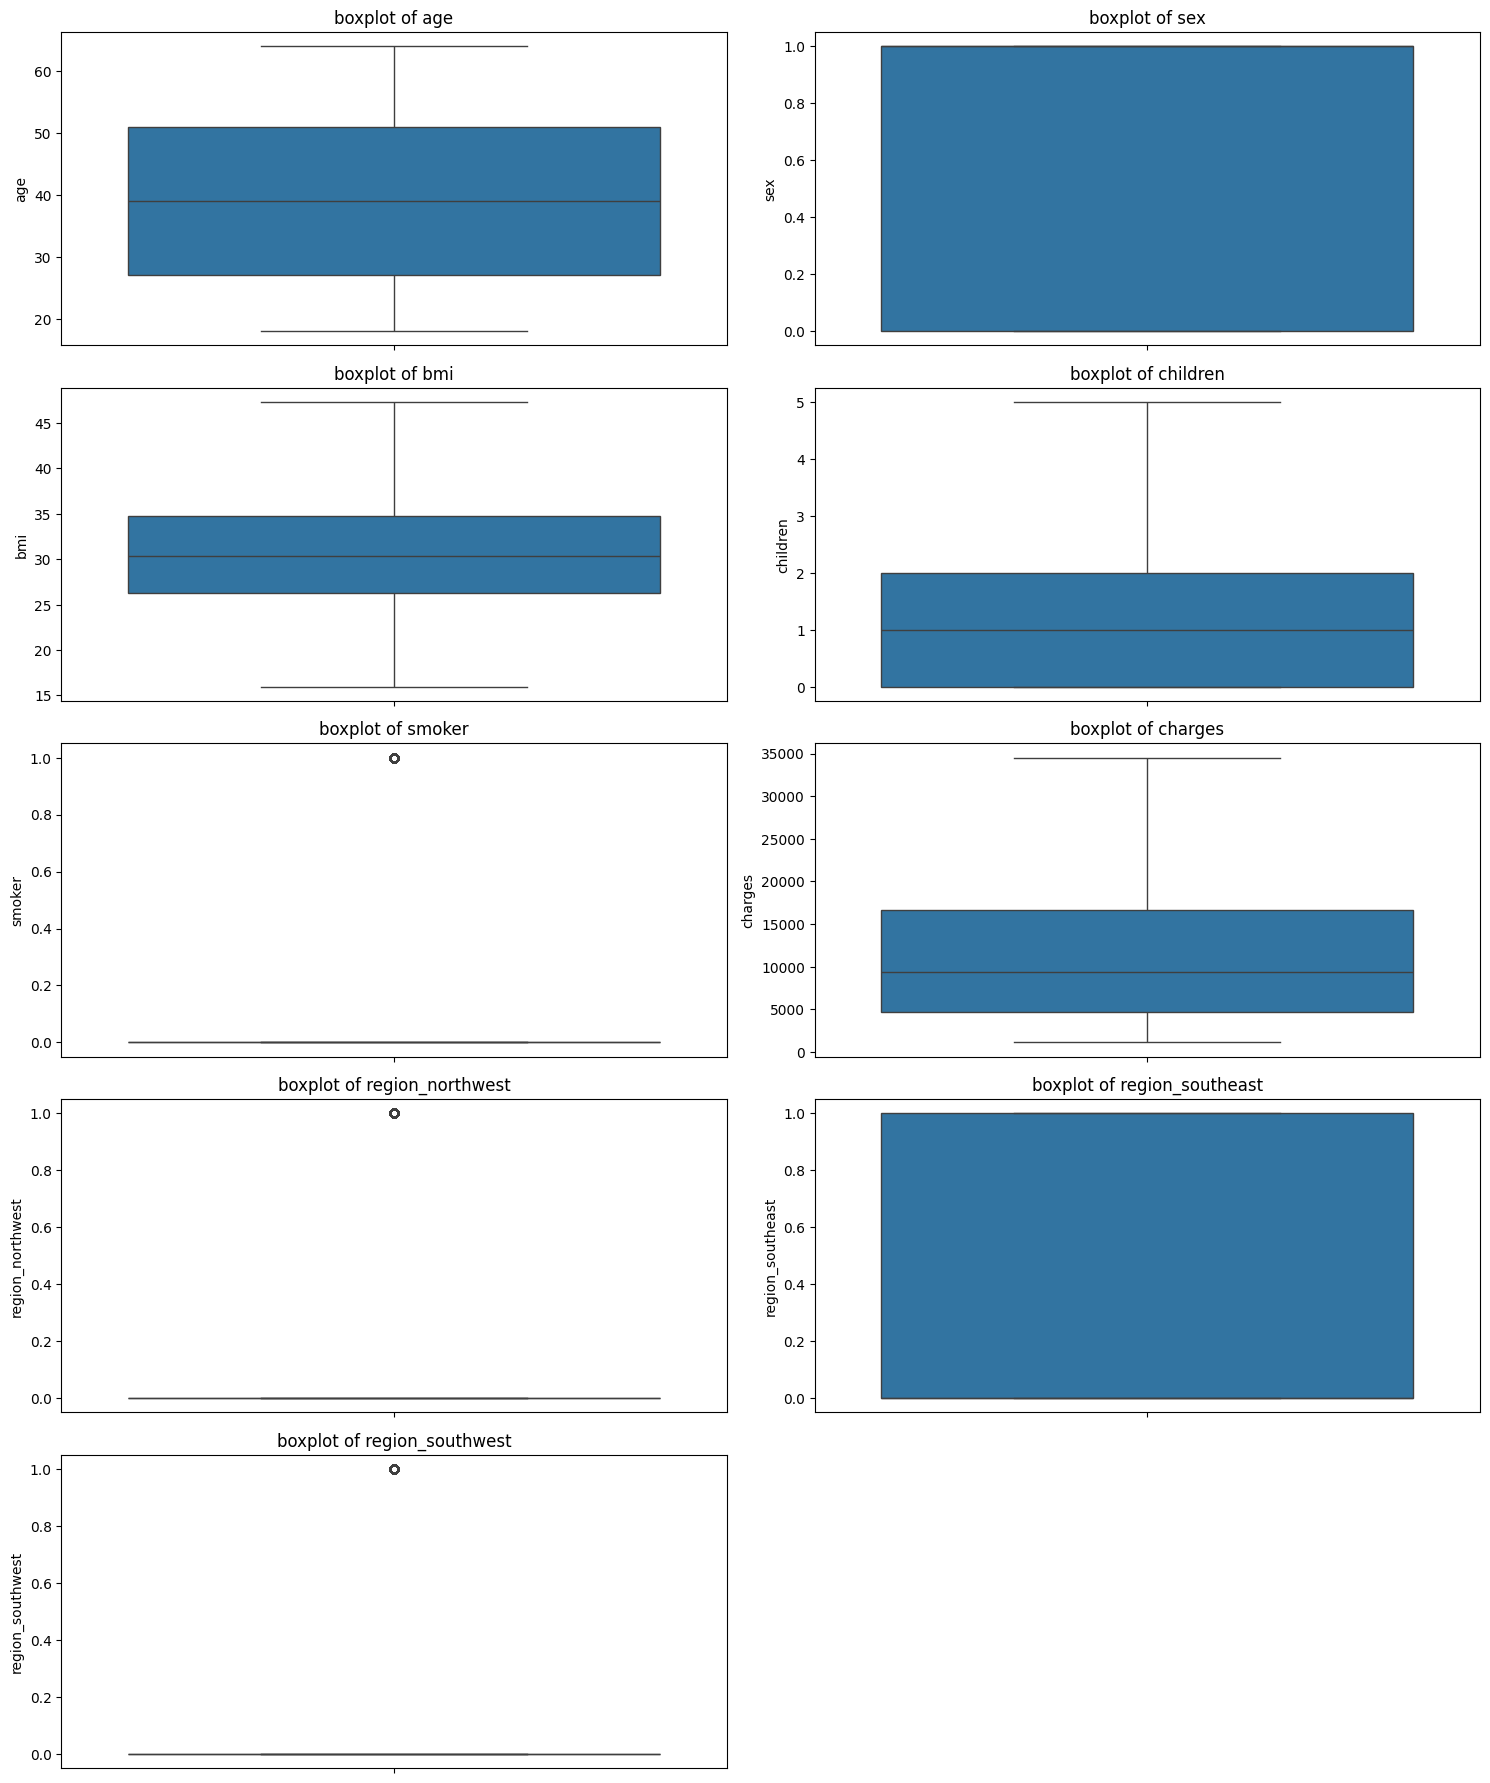

In [10]:
plt.figure(figsize=(15 , 25))
plot_index = 1
for col in df.columns:
    if plot_index > 14:
        break
    plt.subplot(7 , 2 , plot_index)
    sns.boxplot(df[col])
    plt.title(f"boxplot of {col}")
    plot_index += 1
plt.tight_layout()
plt.show()

## Check Skewness and Normalization

C:\Users\ah266\AppData\Local\Temp\ipykernel_19564\4139054802.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
C:\Users\ah266\AppData\Local\Temp\ipykernel_19564\4139054802.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
C:\Users\ah266\AppData\Local\Temp\ipykernel_19564\41

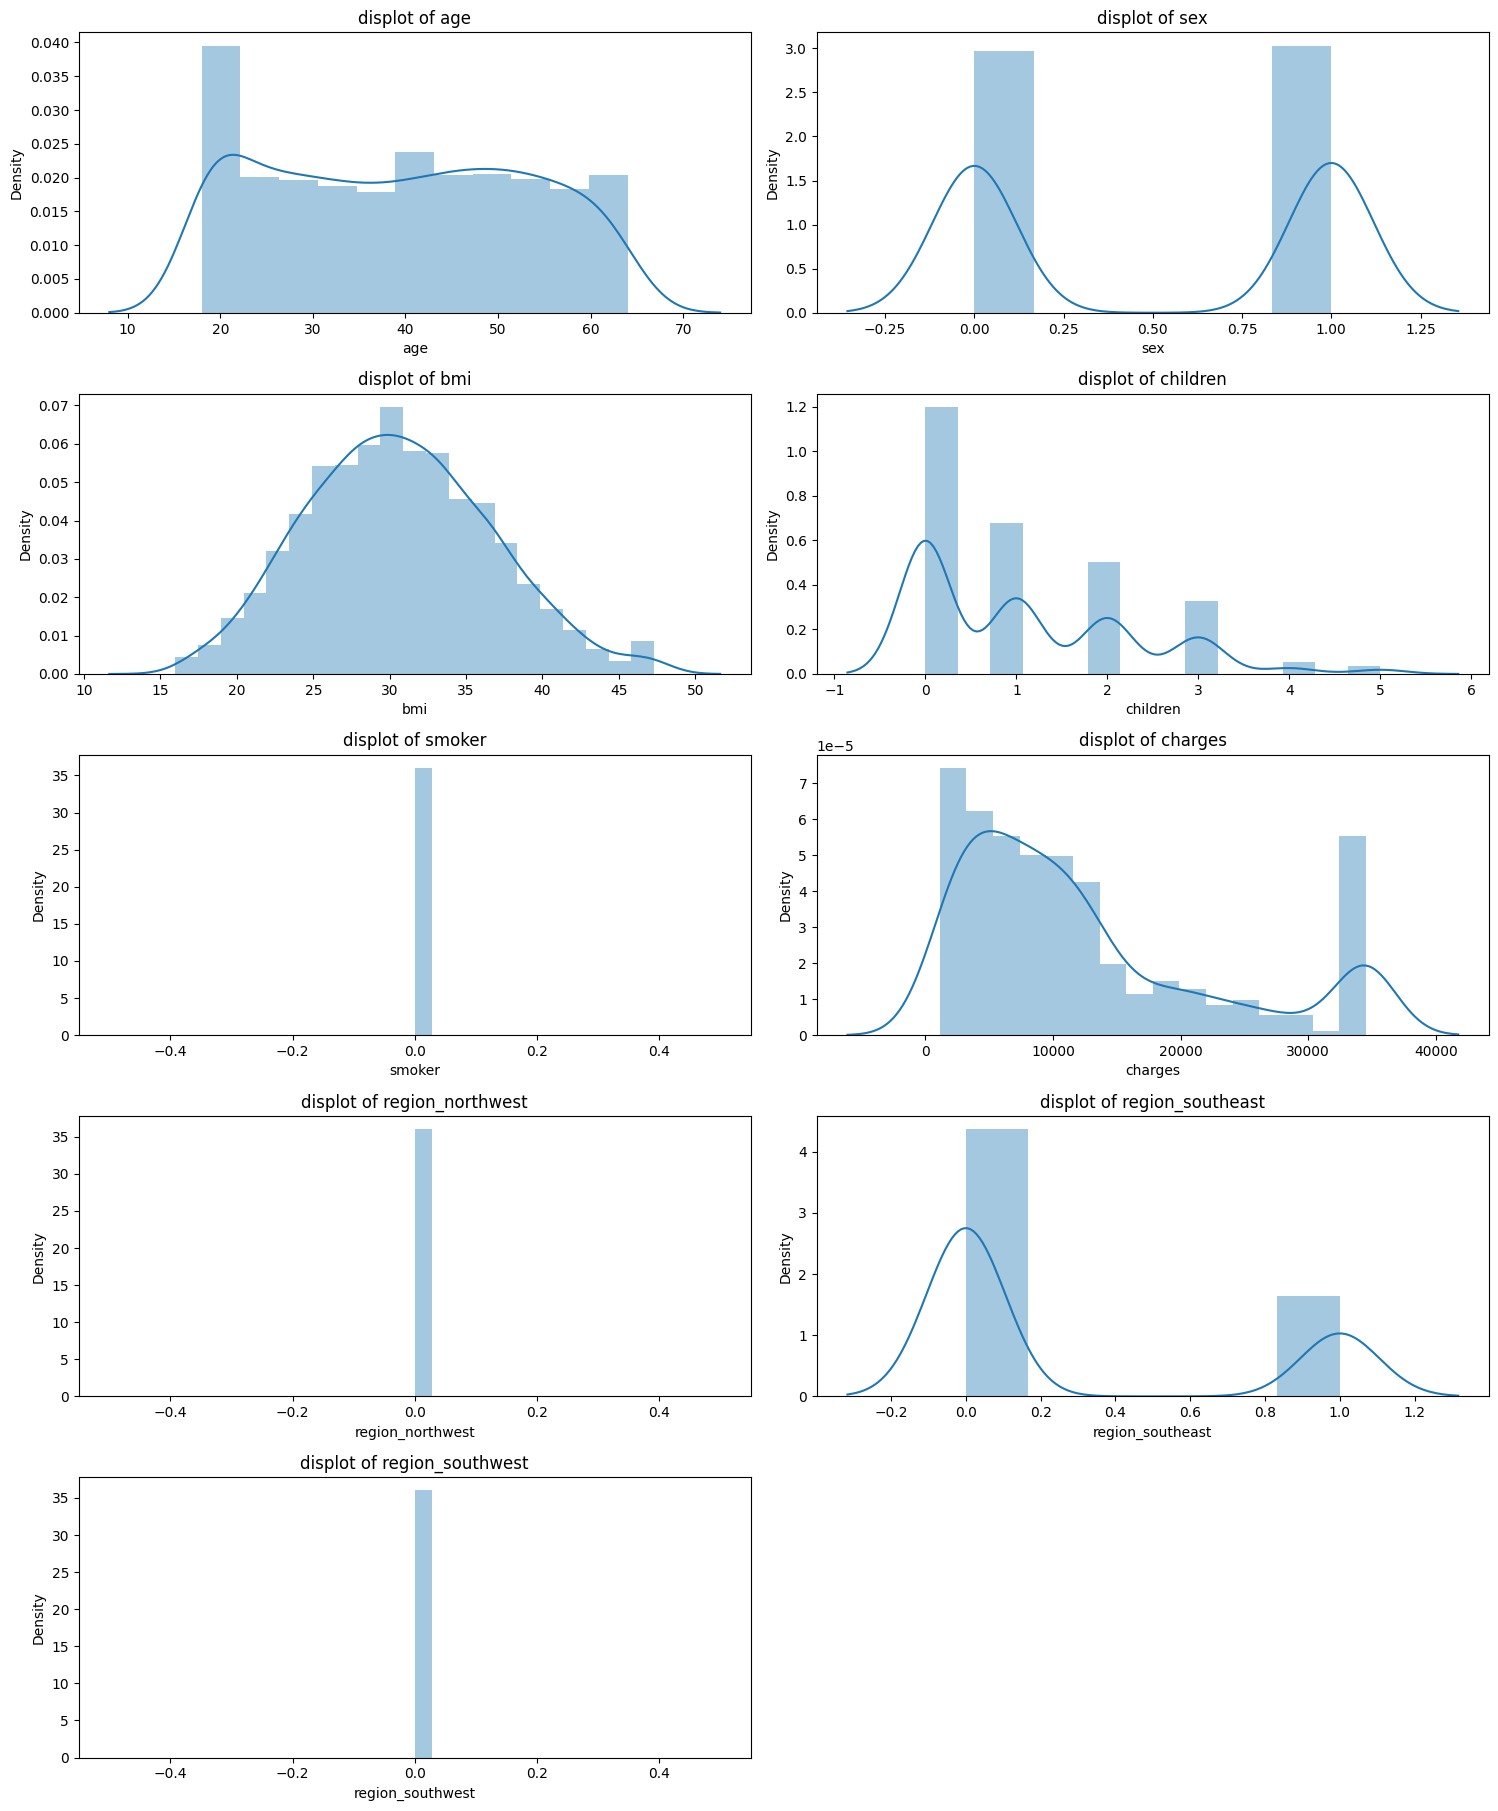

In [33]:
plt.figure(figsize=(15 , 25))
plot_index = 1
for col in df.columns:
    if plot_index > 14:
        break
    plt.subplot(7 , 2 , plot_index)
    sns.distplot(df[col])
    plt.title(f"displot of {col}")
    plot_index += 1
plt.tight_layout()
plt.show()

## Cap the Outlier

In [5]:
for col in df.iloc[: , [2]]:
    percentile25 = df[col].quantile(0.25)
    percentile75 = df[col].quantile(0.75)
    iqr = percentile75 - percentile25
    upper = percentile75 + 1.5*iqr
    lower = percentile25 - 1.5*iqr
    df[col] = np.where(
        df[col] > upper,
        upper,
        np.where(
            df[col] < lower ,
            lower ,
            df[col]
        )
    )

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor , GradientBoostingRegressor , AdaBoostRegressor 
from lightgbm import LGBMRegressor 
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score , root_mean_squared_error 
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV , cross_val_score , cross_val_predict 
from xgboost import XGBRegressor 
from catboost import CatBoostRegressor

In [7]:
x = df.iloc[: , [0 , 1,2,3,4,6,7,8]]
y = df.iloc[: , -4]
x

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,0,0,1
1,18,1,33.770,1,0,0,1,0
2,28,1,33.000,3,0,0,1,0
3,33,1,22.705,0,0,1,0,0
4,32,1,28.880,0,0,1,0,0
...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,1,0,0
1334,18,0,31.920,0,0,0,0,0
1335,18,0,36.850,0,0,0,1,0
1336,21,0,25.800,0,0,0,0,1


## Log transformation on target column

In [8]:
y = np.log1p(y)

In [9]:
X_train , X_test , y_train , y_test = train_test_split(x , y , test_size=0.2  ,  random_state=42)

## Linear Regression

In [10]:
lr = LinearRegression()
lr.fit(X_train , y_train)
pre_lr = lr.predict(X_test)
new_pre_lr = np.expm1(pre_lr)
new_ytest = np.expm1(y_test)
r2 = r2_score(new_ytest , new_pre_lr)
mae = mean_absolute_error(new_ytest , new_pre_lr)
mse = mean_squared_error(new_ytest , new_pre_lr)
rmse = root_mean_squared_error(new_ytest , new_pre_lr)
print(r2)
print(mae)
print(mse)
print(rmse)

0.7187860128086597
3754.9420383173124
51674775.43958481
7188.516915163016


## Decision Tree

In [11]:
dr = DecisionTreeRegressor()
dr.fit(X_train , y_train)
pre_dr = dr.predict(X_test)
new_pre_dr = np.expm1(pre_dr)
new_ytest = np.expm1(y_test)
r2dr = r2_score(new_ytest , new_pre_dr)
maedr = mean_absolute_error(new_ytest , new_pre_dr)
msedr = mean_squared_error(new_ytest , new_pre_dr)
rmsedr = root_mean_squared_error(new_ytest , new_pre_dr)
print(r2dr)
print(maedr)
print(msedr)
print(rmsedr)

0.767537247645072
3053.8868678768663
42716440.408902355
6535.781545377902


## Random Forest

In [12]:
rf = RandomForestRegressor()
rf.fit(X_train , y_train)
pre_rf = rf.predict(X_test)
new_pre_rf = np.expm1(pre_rf)
new_ytest = np.expm1(y_test)
r2rf = r2_score(new_ytest , new_pre_rf)
maerf = mean_absolute_error(new_ytest , new_pre_rf)
mserf = mean_squared_error(new_ytest , new_pre_rf)
rmserf = root_mean_squared_error(new_ytest , new_pre_rf)
print(r2rf)
print(maerf)
print(mserf)
print(rmserf)

0.8939724649550347
2121.3587953770375
19483202.519842546
4413.978083298845


## Cross val

In [13]:
np.mean(cross_val_score(rf , x , y , scoring='r2' , cv=10))

np.float64(0.8088181044245321)

## Hyperparameter tuning

In [18]:
param_grid = { 
    'criterion': ['squared_error', 'absolute_error', 'poisson'] ,
    'bootstrap': [True , False] ,
    'n_estimators': [100 , 200 , 400 , 500 , 700 , 800] ,
    
    'max_depth': [3 , 5 , 9 , 15 , 18 , 25 , 35] ,
    'max_features': ['sqrt', 'log2' , None , 0.25 , 0.50 , 0.75] ,
    'max_leaf_nodes': [5 , 8, 15 ,18 , 25 ,30 , 32 , 45 , None]  ,
    
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor() ,
    param_distributions=param_grid ,
    scoring='r2' ,
    n_jobs= -1 ,
    cv=10 , 
    n_iter=50 
    
)

rf_search.fit(X_train , y_train)
print(f"best params {rf_search.best_params_}")
print(f"best score {rf_search.best_score_}")

best params {'n_estimators': 500, 'max_leaf_nodes': 30, 'max_features': None, 'max_depth': 5, 'criterion': 'poisson', 'bootstrap': True}
best score 0.8028774971776558


## Gradient boosting

In [14]:
gb = GradientBoostingRegressor()
gb.fit(X_train , y_train)
pre_gb = gb.predict(X_test)
new_pre_gb = np.expm1(pre_gb)
new_ytest = np.expm1(y_test)
r2gb = r2_score(new_ytest , new_pre_gb)
maegb = mean_absolute_error(new_ytest , new_pre_gb)
msegb = mean_squared_error(new_ytest , new_pre_gb)
rmsegb = root_mean_squared_error(new_ytest , new_pre_gb)
print(r2gb)
print(maegb)
print(msegb)
print(rmsegb)

0.8964918477702447
2117.1740464956624
19020250.649906762
4361.221233772343


In [15]:
from sklearn.model_selection import RepeatedKFold

cv = RepeatedKFold(
    n_splits=10,
    n_repeats=5,
    random_state=42
)
np.mean(cross_val_score(gb , x , y , scoring='r2' , cv=cv))

np.float64(0.831815616348836)

In [19]:
param_grid = {
    'loss': ['squared_error', 'absolute_error'] ,
    'learning_rate': [0.01,0.03,0.05,0.1] ,
    'n_estimators': [100 , 200 , 300 , 500] ,
    'criterion': ['friedman_mse', 'squared_error'] ,
    'max_depth': [2 , 3 ,4 , 5 ] ,
    'max_features': ['sqrt', 'log2' , None , 0.25 , 0.50 , 0.75] ,
    'max_leaf_nodes': [5 , 8, 15 ,18 , 25 ,30 , 32 , 45 , None]  ,
    
}

rf_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor() ,
    param_distributions=param_grid ,
    scoring='r2' ,
    n_jobs= -1 ,
    cv=10 ,
    n_iter=50
    
)

rf_search.fit(X_train , y_train)
print(f"best params {rf_search.best_params_}")
print(f"best score {rf_search.best_score_}")

best params {'n_estimators': 100, 'max_leaf_nodes': 15, 'max_features': None, 'max_depth': 4, 'loss': 'squared_error', 'learning_rate': 0.03, 'criterion': 'squared_error'}
best score 0.7995355178014313


In [ ]:
param_grid = {
    'loss': ['squared_error', 'absolute_error', 'huber', 'quantile'] ,
    'learning_rate': [0.1 , 0.2 , 0.4 , 0.5 , 0.7 , 0.8 , 1.0] ,
    'n_estimators': [100 , 200 , 400 , 500 , 700 , 800] ,
    'criterion': ['friedman_mse', 'squared_error'] ,
    'max_depth': [3 , 5 , 9 , 15 , 18 , 25 , 35] ,
    'max_features': ['sqrt', 'log2' , None] ,
    'max_leaf_nodes': [5 , 8, 15 ,18 , 25 ,30 , 32 , 45 , None]  ,
    'alpha': [0.2 , 0.3 , 0.4 , 0.5 , 0.6 , 0.7 , 0.8 ] ,
}

gd_search = GridSearchCV(
    estimator=GradientBoostingRegressor() ,
    param_grid=param_grid ,
    scoring='r2' ,
    n_jobs= -1 ,
    cv=10 
    
)

gd_search.fit(X_train , y_train)
print(f"best params {gd_search.best_params_}")
print(f"best score {gd_search.best_score_}")

In [25]:
gb.feature_importances_

array([0.42008061, 0.00515916, 0.0448723 , 0.04367094, 0.47822598,
       0.00108813, 0.00406356, 0.00283932])

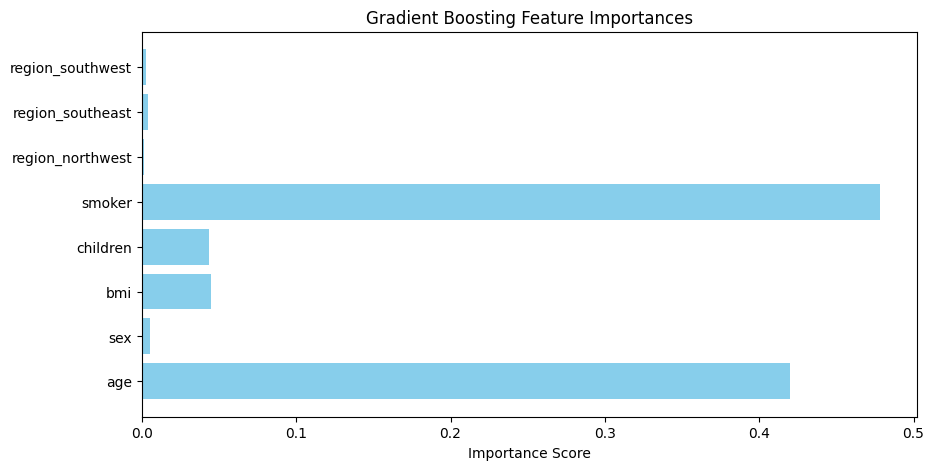

In [32]:
# Plot
plt.figure(figsize=(10, 5))
plt.barh(X_train.columns , gb.feature_importances_, color='skyblue')
plt.xlabel('Importance Score')
plt.title('Gradient Boosting Feature Importances')
plt.show()


## Adaboost

In [14]:
ab = AdaBoostRegressor()
ab.fit(X_train , y_train)
pre_ab = ab.predict(X_test)
r2ab = r2_score(y_test , pre_ab)
maeab = mean_absolute_error(y_test , pre_ab)
mseab = mean_squared_error(y_test , pre_ab)
rmseab = root_mean_squared_error(y_test , pre_ab)
print(r2ab)
print(maeab)
print(mseab)
print(rmseab)

0.8352092683139758
3224.54769136461
17056899.475405376
4129.999936489755


## LGMR

In [16]:
lg = LGBMRegressor(n_estimators=300 , learning_rate=0.03 , max_depth=4 , num_leaves=15)
lg.fit(X_train , y_train)
pre_lg = lg.predict(X_test)
new_pre_lg = np.expm1(pre_lg)
new_ytest = np.expm1(y_test)
r2lg = r2_score(new_ytest , new_pre_lg)
maelg = mean_absolute_error(new_ytest , new_pre_lg)
mselg = mean_squared_error(new_ytest , new_pre_lg)
rmselg = root_mean_squared_error(new_ytest , new_pre_lg)
print(r2lg)
print(maelg)
print(mselg)
print(rmselg)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001052 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 317
[LightGBM] [Info] Number of data points in the train set: 1069, number of used features: 8
[LightGBM] [Info] Start training from score 9.091785
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

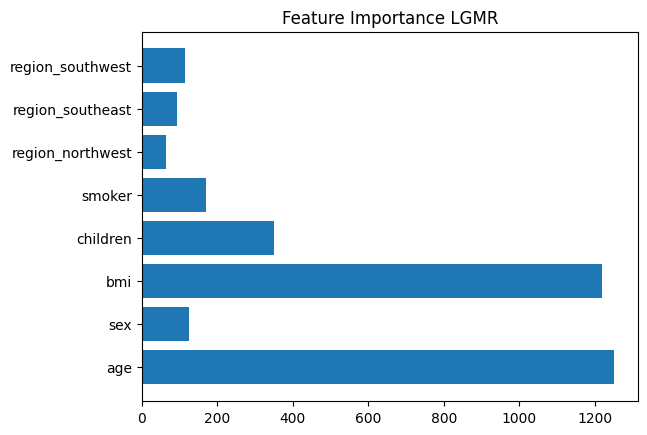

In [21]:
plt.barh(X_train.columns , lg.feature_importances_ )
plt.title('Feature Importance LGMR')
plt.show()

In [22]:
np.mean(cross_val_score(lg , x , y , scoring='r2' , cv=10))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000321 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 319
[LightGBM] [Info] Number of data points in the train set: 1203, number of used features: 8
[LightGBM] [Info] Start training from score 9.097892
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

np.float64(0.831941133945225)

## XGBoost

In [17]:
xgb = XGBRegressor(n_estimators=300,
    learning_rate=0.02,
    max_depth=5,
    random_state=42)
xgb.fit(X_train , y_train)
pre_xgb = xgb.predict(X_test)
new_pre_xgb = np.expm1(pre_xgb)
new_test = np.expm1(y_test)
r2xgb = r2_score(new_test , new_pre_xgb)
maexgb = mean_absolute_error(new_test , new_pre_xgb)
msexgb = mean_squared_error(new_test , new_pre_xgb)
rmsexgb = root_mean_squared_error(new_test , new_pre_xgb)
print(r2xgb)
print(maexgb)
print(msexgb)
print(rmsexgb)

0.8993229083113805
1988.803155647066
18500026.107805602
4301.165668490997


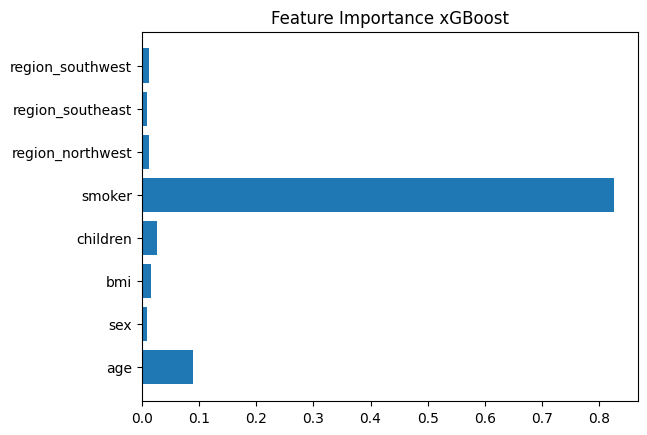

In [27]:
plt.barh(X_train.columns , xgb.feature_importances_ )
plt.title('Feature Importance xGBoost')
plt.show()

In [28]:
np.mean(cross_val_score(xgb , x , y , scoring='r2' , cv=10))

np.float64(0.8259769618546837)

In [60]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

search = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=10,
    scoring="r2",
    n_iter=30,
    n_jobs=-1
)

search.fit(X_train, y_train)

print(search.best_params_)
print(search.best_score_)

{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
0.8056666581447562


## CatBoost

In [18]:
ct = CatBoostRegressor(iterations=400,
    learning_rate=0.03,
    depth=4,
    random_state=42,
    verbose=0)
ct.fit(X_train , y_train)
pre_ct = ct.predict(X_test)
new_pre_ct = np.expm1(pre_ct)
new_ytest = np.expm1(y_test)
r2ct = r2_score(new_ytest , new_pre_ct)
maect = mean_absolute_error(new_ytest , new_pre_ct)
msect = mean_squared_error(new_ytest , new_pre_ct)
rmsect = root_mean_squared_error(new_ytest , new_pre_ct)
print(r2ct)
print(maect)
print(msect)
print(rmsect)

0.8962470420772928
2115.5996932540697
19065235.180498466
4366.375519867533


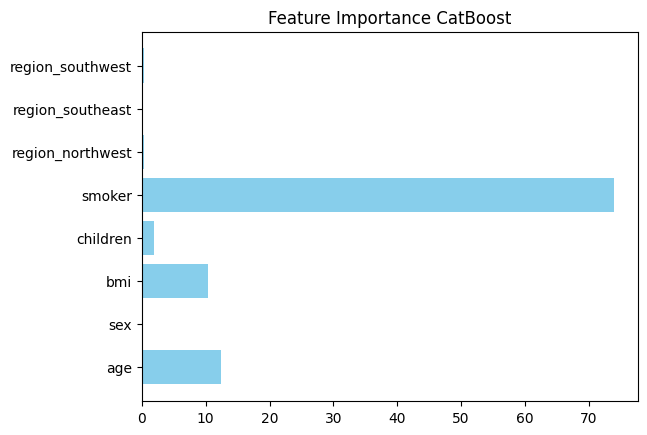

In [63]:
plt.barh(X_train.columns , ct.feature_importances_ , color='skyblue')
plt.title('Feature Importance CatBoost')
plt.show()

In [19]:
np.mean(cross_val_score(ct , x , y , scoring='r2' , cv=10))

np.float64(0.8336219754403082)

In [36]:
param_grid = {
    "iterations": [200, 500, 700],
    "learning_rate": [0.01, 0.05, 0.1],
    "depth": [4, 6, 8],
    "l2_leaf_reg": [1, 3, 5, 7]
}

search = RandomizedSearchCV(
    CatBoostRegressor(verbose=0),
    param_grid,
    cv=10,
    scoring="r2",
    n_iter=20,
    n_jobs=-1
)

search.fit(X_train, y_train)

print(search.best_params_)
print(search.best_score_)

{'learning_rate': 0.01, 'l2_leaf_reg': 5, 'iterations': 700, 'depth': 4}
0.8081531400346871


In [20]:
import joblib

joblib.dump(ct, r"C:\Users\ah266\OneDrive\Documents\Medical_Insurance_Predictor\models\catboost_model.pkl")

['C:\\Users\\ah266\\OneDrive\\Documents\\Medical_Insurance_Predictor\\models\\catboost_model.pkl']

In [21]:
print(df.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='str')


## Test the Model

In [ ]:
import numpy as np

sample = np.array([[35, 1, 28.5, 2, 0, 1, 0, 0]])

prediction_log = ct.predict(sample)

prediction = np.expm1(prediction_log)

print(prediction[0])

6330.4652110782845 2
